# IMPORT LIBRARIES

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
import warnings
warnings.filterwarnings('ignore')

#  LOAD DATASET

In [30]:
df=pd.read_csv('/Users/hello/Documents/ASDS@JU/Introduction to Data Science/Project/Dataset/taxi_trip_pricing.csv')

In [31]:
print("Shape:", df.shape)


Shape: (1000, 11)


In [32]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [33]:
print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB
None


In [34]:
print("\nBasic Statistics:")
print(df.describe())


Basic Statistics:
       Trip_Distance_km  Passenger_Count   Base_Fare  Per_Km_Rate  \
count        950.000000       950.000000  950.000000   950.000000   
mean          27.070547         2.476842    3.502989     1.233316   
std           19.905300         1.102249    0.870162     0.429816   
min            1.230000         1.000000    2.010000     0.500000   
25%           12.632500         1.250000    2.730000     0.860000   
50%           25.830000         2.000000    3.520000     1.220000   
75%           38.405000         3.000000    4.260000     1.610000   
max          146.067047         4.000000    5.000000     2.000000   

       Per_Minute_Rate  Trip_Duration_Minutes  Trip_Price  
count       950.000000             950.000000  951.000000  
mean          0.292916              62.118116   56.874773  
std           0.115592              32.154406   40.469791  
min           0.100000               5.010000    6.126900  
25%           0.190000              35.882500   33.742650  

In [35]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64


In [36]:
# Numerical columns: fill with median
num_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare',
            'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']
 
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
 
# Categorical columns: fill with mode
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
 
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [37]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


# EDA - Exploratory Data Analysis

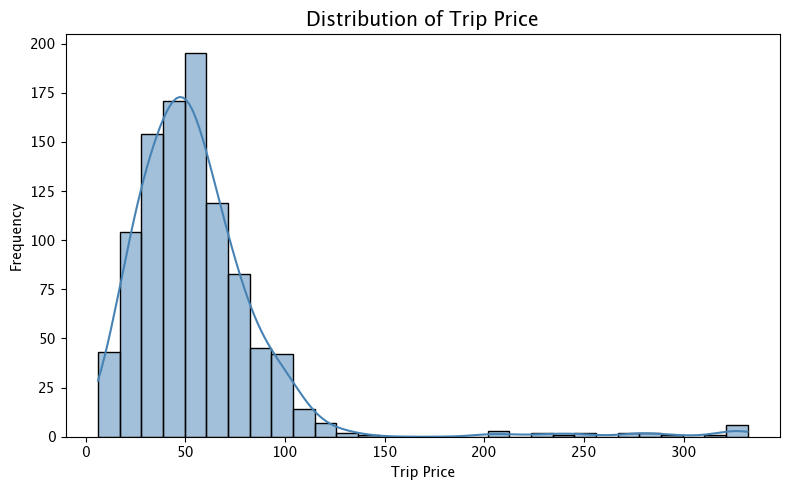

In [38]:
# Visualization 1: Trip Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Trip_Price'], kde=True, color='steelblue', bins=30)
plt.title('Distribution of Trip Price', fontsize=14, fontweight='bold')
plt.xlabel('Trip Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('viz1_trip_price_distribution.png', dpi=150)
plt.show()

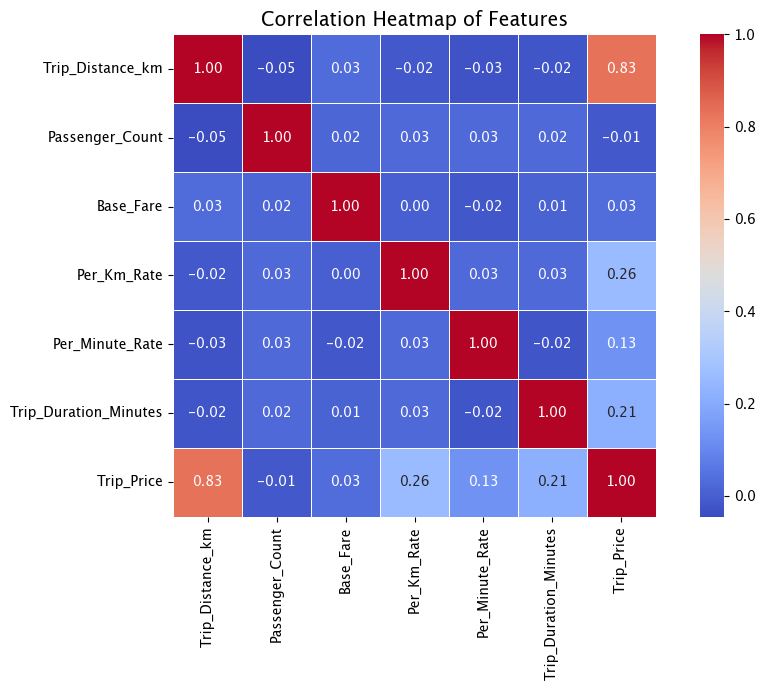

In [39]:
# Visualization 2 : Correlation Heatmap
plt.figure(figsize=(10, 7))
corr_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare',
             'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_correlation_heatmap.png', dpi=150)
plt.show()

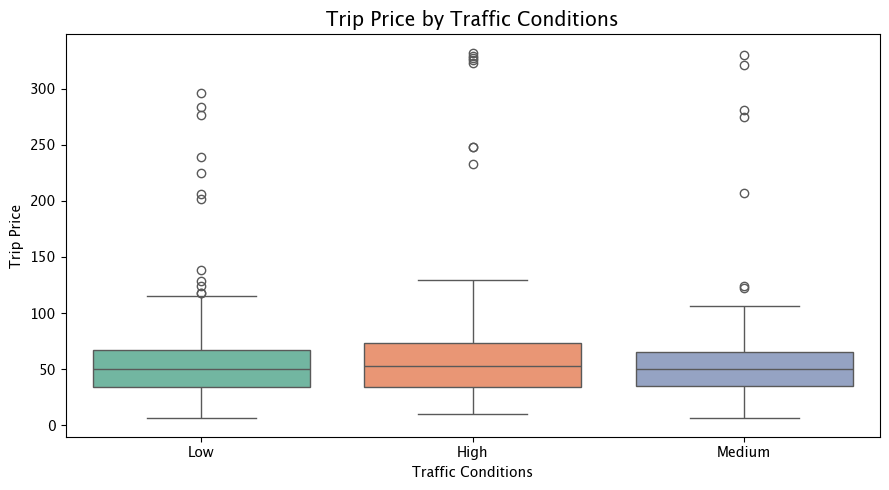

In [40]:
# Visualization 3 : Trip Price by Traffic Conditions
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Traffic_Conditions', y='Trip_Price', palette='Set2')
plt.title('Trip Price by Traffic Conditions', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Conditions')
plt.ylabel('Trip Price')
plt.tight_layout()
plt.savefig('viz3_price_by_traffic.png', dpi=150)
plt.show()

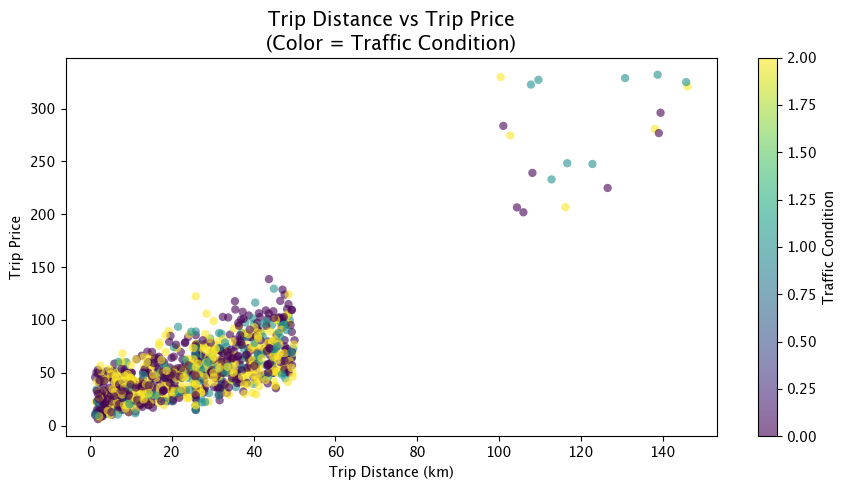

In [41]:
# Visualization 4 : Trip Distance vs Trip Price

plt.figure(figsize=(9, 5))
traffic_map = {v: i for i, v in enumerate(df['Traffic_Conditions'].unique())}
traffic_color = df['Traffic_Conditions'].map(traffic_map)
scatter = plt.scatter(
    df['Trip_Distance_km'], df['Trip_Price'],
    c=traffic_color, cmap='viridis', alpha=0.6, edgecolors='none'
)
plt.colorbar(scatter, label='Traffic Condition')
plt.title('Trip Distance vs Trip Price\n(Color = Traffic Condition)',
          fontsize=14, fontweight='bold')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Trip Price')
plt.tight_layout()
plt.savefig('viz4_distance_vs_price_scatter.png', dpi=150)
plt.show()

#  DATA PREPROCESSING

In [42]:
# Encode Categorical Variables 

le = LabelEncoder()
 
for col in cat_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])
    print(f"\n{col} categories: {le.classes_}")



Time_of_Day categories: ['Afternoon' 'Evening' 'Morning' 'Night']

Day_of_Week categories: ['Weekday' 'Weekend']

Traffic_Conditions categories: ['High' 'Low' 'Medium']

Weather categories: ['Clear' 'Rain' 'Snow']


In [43]:
# Feature Selection
feature_cols = [
    'Trip_Distance_km',
    'Passenger_Count',
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Time_of_Day_encoded',
    'Day_of_Week_encoded',
    'Traffic_Conditions_encoded',
    'Weather_encoded'
]
 
X = df[feature_cols]
y = df['Trip_Price']

In [44]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")


Training set size: 800
Test set size:     200


In [45]:
# 3.6 Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# MODEL 1 : LINEAR REGRESSION

In [46]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [48]:
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
 
print("\n--- Linear Regression Results ---")
print(f"MAE:  {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")


--- Linear Regression Results ---
MAE:  9.8423
RMSE: 13.8223
R²:   0.7700


# MODEL 2: RANDOM FOREST REGRESSOR

In [49]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # RF doesn't need scaling

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
y_pred_rf = rf_model.predict(X_test)

In [51]:
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
 
print("\n--- Random Forest Regressor Results ---")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")


--- Random Forest Regressor Results ---
MAE:  5.4137
RMSE: 7.6913
R²:   0.9288


In [52]:
# MODEL COMPARISON

# SUMMARY

In [53]:
print("\n========== FINAL SUMMARY ==========")
print(f"Dataset size       : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Training samples   : {X_train.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")
print(f"\nLinear Regression  → R²: {r2_lr:.4f} | MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f}")
print(f"Random Forest      → R²: {r2_rf:.4f} | MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f}")
 
better = "Random Forest" if r2_rf > r2_lr else "Linear Regression"
print(f"\nBetter Model: {better}")
print("====================================")


========== FINAL SUMMARY ==========
Dataset size       : 1000 rows, 15 columns
Training samples   : 800
Test samples       : 200

Linear Regression  → R²: 0.7700 | MAE: 9.8423 | RMSE: 13.8223
Random Forest      → R²: 0.9288 | MAE: 5.4137 | RMSE: 7.6913

Better Model: Random Forest
